In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r'C:\Users\kulka\Downloads\ML Project\swiggy_demographic (1).csv')

In [3]:
df.head()

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45502 entries, 0 to 45501
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rider_id              45502 non-null  object 
 1   age                   43648 non-null  float64
 2   ratings               43594 non-null  float64
 3   restaurant_latitude   41872 non-null  float64
 4   restaurant_longitude  41872 non-null  float64
 5   delivery_latitude     41872 non-null  float64
 6   delivery_longitude    41872 non-null  float64
 7   order_date            45502 non-null  object 
 8   weather               44977 non-null  object 
 9   traffic               44992 non-null  object 
 10  vehicle_condition     45502 non-null  int64  
 11  type_of_order         45502 non-null  object 
 12  type_of_vehicle       45502 non-null  object 
 13  multiple_deliveries   44509 non-null  float64
 14  festival              45274 non-null  object 
 15  city_type          

In [5]:
df.isna().sum()

rider_id                   0
age                     1854
ratings                 1908
restaurant_latitude     3630
restaurant_longitude    3630
delivery_latitude       3630
delivery_longitude      3630
order_date                 0
weather                  525
traffic                  510
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries      993
festival                 228
city_type               1198
time_taken                 0
city_name                  0
order_day                  0
order_month                0
order_day_of_week          0
is_weekend                 0
pickup_time_minutes     1640
order_time_hour         1640
order_time_of_day          0
distance                3630
dtype: int64

In [6]:
(df.isna().sum()/len(df)) * 100

rider_id                0.000000
age                     4.074546
ratings                 4.193222
restaurant_latitude     7.977671
restaurant_longitude    7.977671
delivery_latitude       7.977671
delivery_longitude      7.977671
order_date              0.000000
weather                 1.153795
traffic                 1.120830
vehicle_condition       0.000000
type_of_order           0.000000
type_of_vehicle         0.000000
multiple_deliveries     2.182322
festival                0.501077
city_type               2.632851
time_taken              0.000000
city_name               0.000000
order_day               0.000000
order_month             0.000000
order_day_of_week       0.000000
is_weekend              0.000000
pickup_time_minutes     3.604237
order_time_hour         3.604237
order_time_of_day       0.000000
distance                7.977671
dtype: float64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.head()

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138


In [9]:
df.drop(columns = ['rider_id','order_date','restaurant_latitude','restaurant_longitude','delivery_latitude','delivery_longitude'], inplace = True)

## Outliers

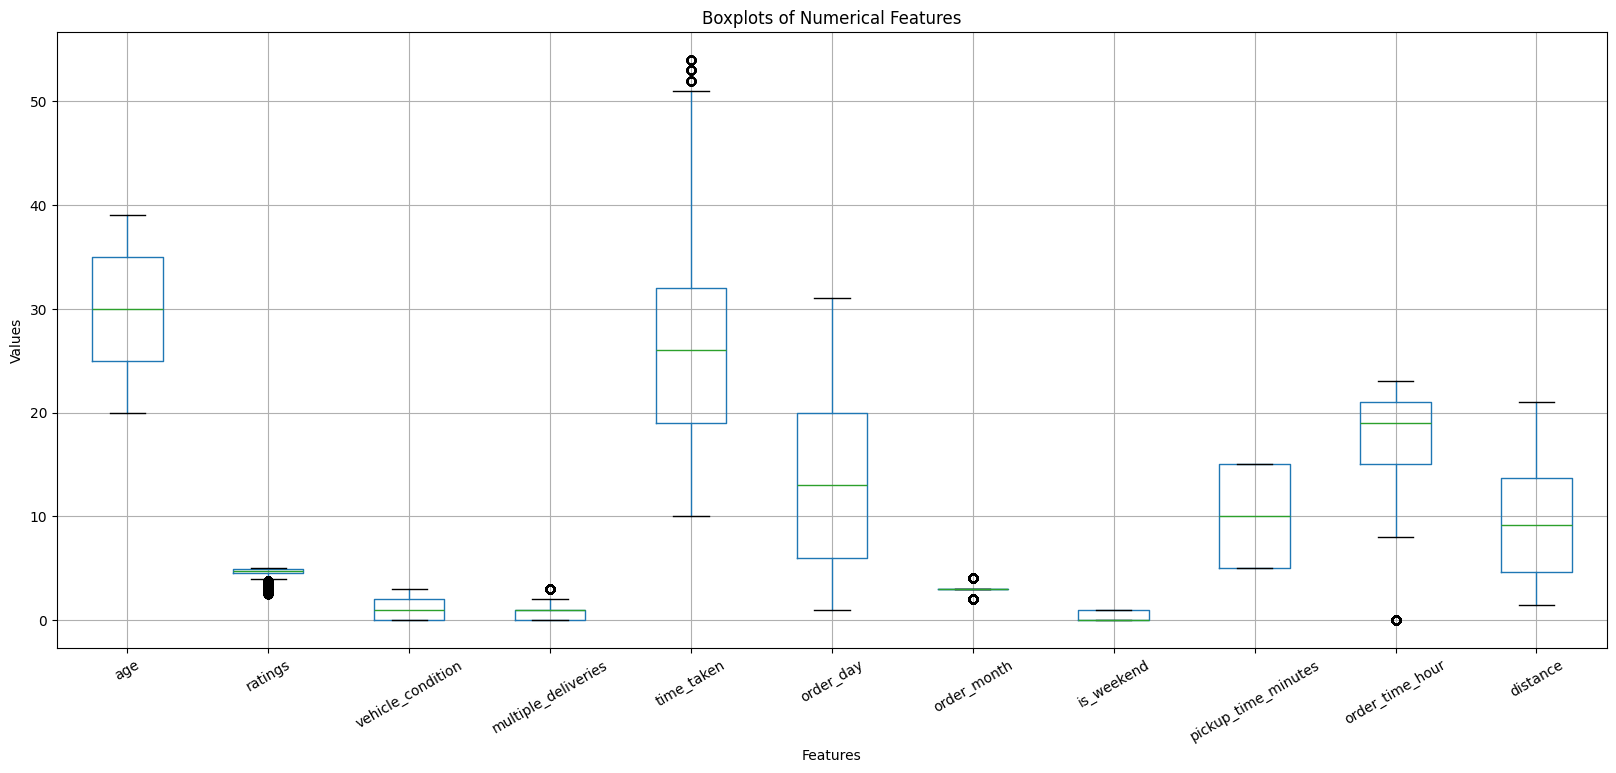

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))
df.boxplot(rot=30)
plt.title("Boxplots of Numerical Features")
plt.xlabel("Features")
plt.ylabel("Values")
plt.show()

## preprocessing

In [11]:
x = df.drop(columns = ['time_taken'])
y = df['time_taken']

In [12]:
df.head()

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138


In [13]:
cat_cols = df.select_dtypes(include = 'object')
cat_cols

,weather,traffic,type_of_order,type_of_vehicle,festival,city_type,city_name,order_day_of_week,order_time_of_day
0,sunny,high,snack,motorcycle,no,urban,INDO,saturday,morning
1,stormy,jam,snack,scooter,no,metropolitian,BANG,friday,evening
2,sandstorms,low,drinks,motorcycle,no,urban,BANG,saturday,morning
3,sunny,medium,buffet,motorcycle,no,metropolitian,COIMB,tuesday,evening
4,cloudy,high,snack,scooter,no,metropolitian,CHEN,saturday,afternoon
...,...,...,...,...,...,...,...,...,...
45497,windy,high,meal,motorcycle,no,metropolitian,JAP,thursday,morning
45498,windy,jam,buffet,motorcycle,no,metropolitian,AGR,wednesday,evening
45499,cloudy,low,drinks,scooter,no,metropolitian,CHEN,friday,night
45500,cloudy,high,snack,motorcycle,no,metropolitian,COIMB,monday,afternoon


In [14]:
num_cols = df.select_dtypes(include= ['int','float64'])
num_cols 

,age,ratings,vehicle_condition,multiple_deliveries,time_taken,order_day,order_month,is_weekend,pickup_time_minutes,order_time_hour,distance
0,37.0,4.9,2,0.0,24,19,3,1,15.0,11.0,3.025149
1,34.0,4.5,2,1.0,33,25,3,0,5.0,19.0,20.183530
2,23.0,4.4,0,1.0,26,19,3,1,15.0,8.0,1.552758
3,38.0,4.7,0,1.0,21,5,4,0,10.0,18.0,7.790401
4,32.0,4.6,1,1.0,30,26,3,1,15.0,13.0,6.210138
...,...,...,...,...,...,...,...,...,...,...,...
45497,30.0,4.8,1,0.0,32,24,3,0,10.0,11.0,1.489846
45498,21.0,4.6,0,1.0,36,16,2,0,15.0,19.0,NaN
45499,30.0,4.9,1,0.0,16,11,3,0,15.0,23.0,4.657195
45500,20.0,4.7,0,1.0,26,7,3,0,5.0,13.0,6.232393


In [15]:
cat_cols.nunique()

weather               6
traffic               4
type_of_order         4
type_of_vehicle       4
festival              2
city_type             3
city_name            22
order_day_of_week     7
order_time_of_day     5
dtype: int64

In [16]:
df['order_time_of_day'].unique()

array(['morning', 'evening', 'afternoon', 'night', 'after_midnight'],
      dtype=object)

In [17]:
num_cols.nunique()

age                      20
ratings                  26
vehicle_condition         4
multiple_deliveries       4
time_taken               45
order_day                30
order_month               3
is_weekend                2
pickup_time_minutes       3
order_time_hour          17
distance               4362
dtype: int64

In [18]:
df['is_weekend'].unique()

array([1, 0])

In [19]:
ordinal_cols = ['traffic','city_type','order_time_of_day']

nominal_cols = ['weather', 'type_of_order', 'type_of_vehicle', 'festival', 'city_name','order_day_of_week']

descrete_cols = ['vehicle_condition','multiple_deliveries','is_weekend']

numerical_cols = ['age', 'ratings','order_day', 'order_month', 'pickup_time_minutes', 'order_time_hour', 'distance']

In [20]:
traffic = ["low", "medium", "high", "jam"]

city_type = ['semi-urban','urban','metropolitian']

order_time_of_day = ['after_midnight','morning', 'afternoon', 'evening', 'night']

## With Pipeline

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder,StandardScaler,PowerTransformer

In [22]:
numerical_pipe = Pipeline([('simple imputer', SimpleImputer(strategy= 'median')),
                     ('transformation', PowerTransformer()),
                     ('scaler', StandardScaler())])

numerical_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('simple imputer', ...), ('transformation', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive es

In [23]:
descrete_pipe = Pipeline([('descrete_imputer', SimpleImputer(strategy='most_frequent'))])

descrete_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('descrete_imputer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for

In [24]:
nominal_pipe = Pipeline([('nominal_imputer', SimpleImputer(strategy='most_frequent')),
                        ('ohe_encoding', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))])
nominal_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('nominal_imputer', ...), ('ohe_encoding', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive e

In [25]:
ordinal_pipe = Pipeline([('ord_imputer', SimpleImputer(strategy= 'most_frequent')),
                        ('ord_encoding', OrdinalEncoder(categories= [traffic,city_type,order_time_of_day],
                          handle_unknown= 'use_encoded_value',
                          unknown_value=-1))])

ordinal_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('ord_imputer', ...), ('ord_encoding', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estim

## Power Transform use to overcome Outliers

In [26]:
from sklearn.compose import ColumnTransformer

In [27]:
preprocessing = ColumnTransformer([
    ("num", numerical_pipe, numerical_cols),
    ("ord", ordinal_pipe, ordinal_cols),
    ("nom", nominal_pipe, nominal_cols),
    ("dis", descrete_pipe, descrete_cols)
])

preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

## Train Test Split

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size= 0.2, random_state= 23)

In [30]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((36401, 19), (9101, 19), (36401,), (9101,))

In [31]:
preprocessing.fit_transform(x_train)

array([[ 9.28191240e-02, -7.61781330e-01,  6.68125783e-02, ...,
         2.00000000e+00,  1.00000000e+00,  1.00000000e+00],
       [-6.21061256e-01,  1.73798519e+00,  2.81240401e-01, ...,
         1.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       [-1.72502628e+00, -5.13324450e-04,  1.36410524e+00, ...,
         0.00000000e+00,  1.00000000e+00,  1.00000000e+00],
       ...,
       [-1.16753272e+00, -4.13415745e-01,  3.83697733e-01, ...,
         1.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       [-1.35205836e+00,  1.06237922e+00,  2.81240401e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-8.02088304e-01, -4.13415745e-01,  1.36410524e+00, ...,
         1.00000000e+00,  0.00000000e+00,  1.00000000e+00]],
      shape=(36401, 58))

In [32]:
df['traffic'].unique()

array(['high', 'jam', 'low', 'medium', nan], dtype=object)

In [33]:
x_train_process = preprocessing.fit_transform(x_train)
x_test_process = preprocessing.transform(x_test)

In [34]:
feature_names = preprocessing.get_feature_names_out()

In [35]:
x_train_process = pd.DataFrame(
    x_train_process,
    columns=feature_names
)

x_test_process = pd.DataFrame(
    x_test_process,
    columns=feature_names
)

print(x_train_process.shape)
print(x_test_process.shape)

(36401, 58)
(9101, 58)


## Model Selection and Evaluation Metrics

In [36]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error,r2_score

In [37]:
dt = DecisionTreeRegressor()
svr = SVR()
xgboost = XGBRegressor()
lr = LinearRegression()
rf = RandomForestRegressor()
gb = GradientBoostingRegressor()

In [38]:
dt.fit(x_train_process, y_train)
y_pred = dt.predict(x_test_process)

print('mean squared error:', mean_squared_error(y_test,y_pred))
print('root mean squared error:', root_mean_squared_error(y_test,y_pred))
print('mean absolute error:', mean_absolute_error(y_test,y_pred))
print('r2 score:', r2_score(y_test,y_pred))

mean squared error: 31.422041533897374
root mean squared error: 5.605536685625862
mean absolute error: 4.225469728601253
r2 score: 0.646587100815827


In [39]:
svr.fit(x_train_process, y_train)
y_pred = svr.predict(x_test_process)

print('mean squared error:', mean_squared_error(y_test,y_pred))
print('root mean squared error:', root_mean_squared_error(y_test,y_pred))
print('mean absolute error:', mean_absolute_error(y_test,y_pred))
print('r2 score:', r2_score(y_test,y_pred))

mean squared error: 27.23957593326842
root mean squared error: 5.219154714440684
mean absolute error: 4.120305351525767
r2 score: 0.6936285157430453


In [40]:
xgboost.fit(x_train_process, y_train)
y_pred = xgboost.predict(x_test_process)

print('mean squared error:', mean_squared_error(y_test,y_pred))
print('root mean squared error:', root_mean_squared_error(y_test,y_pred))
print('mean absolute error:', mean_absolute_error(y_test,y_pred))
print('r2 score:', r2_score(y_test,y_pred))

mean squared error: 16.657670974731445
root mean squared error: 4.081380844116211
mean absolute error: 3.239807367324829
r2 score: 0.8126462697982788


In [41]:
lr.fit(x_train_process, y_train)
y_pred = lr.predict(x_test_process)

print('mean squared error:', mean_squared_error(y_test,y_pred))
print('root mean squared error:', root_mean_squared_error(y_test,y_pred))
print('mean absolute error:', mean_absolute_error(y_test,y_pred))
print('r2 score:', r2_score(y_test,y_pred))

mean squared error: 38.87781010358672
root mean squared error: 6.235207302374695
mean absolute error: 4.973269268761967
r2 score: 0.5627298892142953


In [42]:
rf.fit(x_train_process, y_train)
y_pred = rf.predict(x_test_process)

print('mean squared error:', mean_squared_error(y_test,y_pred))
print('root mean squared error:', root_mean_squared_error(y_test,y_pred))
print('mean absolute error:', mean_absolute_error(y_test,y_pred))
print('r2 score:', r2_score(y_test,y_pred))

mean squared error: 16.94319456103725
root mean squared error: 4.116211190043248
mean absolute error: 3.243255686188331
r2 score: 0.8094349310563405


In [43]:
gb.fit(x_train_process, y_train)
y_pred = gb.predict(x_test_process)

print('mean squared error:', mean_squared_error(y_test,y_pred))
print('root mean squared error:', root_mean_squared_error(y_test,y_pred))
print('mean absolute error:', mean_absolute_error(y_test,y_pred))
print('r2 score:', r2_score(y_test,y_pred))

mean squared error: 21.229033422214698
root mean squared error: 4.6074975227573045
mean absolute error: 3.7064746647176454
r2 score: 0.7612308468076794


In [44]:
pipe = Pipeline([('pre',preprocessing),
                ('xgboost',XGBRegressor())])
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('xgboost', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o

In [45]:
pipe.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('xgboost', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['age','ratings','weather',...,'order_time_hour','order_time_of_day', 'distance']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of

## Cross Validation

In [46]:
from sklearn.model_selection import KFold, cross_val_score

In [47]:
kfold = KFold(n_splits = 5,shuffle = True,random_state= 23)
kfold

KFold(n_splits=5, random_state=23, shuffle=True)

In [48]:
scores = cross_val_score(
    xgboost,
    x_train_process,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Cross Validation Scores:", scores)
print("Average R2 Score:", scores.mean())

Cross Validation Scores: [0.79800618 0.80221587 0.80472022 0.80871463 0.80620348]
Average R2 Score: 0.8039720773696899


In [49]:
from sklearn.model_selection import RandomizedSearchCV

In [50]:
xg_boost = XGBRegressor()
search_space = {
    "n_estimators": [100, 200, 300, 500,1500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2, 0.5],
    "max_depth": [3, 5, 7, 9, 15],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10]
}

In [51]:
random_search = RandomizedSearchCV(
    estimator=xg_boost,
    param_distributions=search_space,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=23,
    n_jobs=-1
)

random_search.fit(x_train_process, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Best Parameters: {'subsample': 1.0, 'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.6}
Best Score: 0.8141585469245911


## Model Deployment